In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
from pyomo.environ import *
from optimization_utils import *
from param_loader import METANET_Params
from simulation_utils import *
import os

In [3]:
# rho_hat = df["Density"]
# q_hat = df["Flow"]
# print(max(q_hat))
# C_i = np.mean(sorted(q_hat)[-5:])
# print("C_i", C_i)
# K = len(rho_hat)

q_hat = np.load("data/flow_10sec_400m_1hr.npy")
print(np.max(q_hat))
rho_hat = np.load("data/density_10sec_400m_1hr.npy")
v_hat = q_hat / rho_hat
print(rho_hat.shape)
flattened_q_hat = q_hat.flatten()
print(max(flattened_q_hat))
flattened_rho_hat = rho_hat.flatten()
C_i = np.mean(np.sort(flattened_q_hat)[-5:])
print("C_i", C_i)
K = len(flattened_rho_hat)
print("K", K)

rho_hat = np.where(rho_hat == 0.0, 1e-3, rho_hat)
q_hat = np.where(q_hat == 0.0, 1e-3, q_hat)



6773.200199999966
(360, 16)
6773.200199999966
C_i 6718.716719999977
K 5760


In [10]:
random.seed(1)
np.random.seed(1)

T = 10 / 3600
l = 0.4
num_calibrated_segments = 14
include_ramping = False
varylanes = False
tolerances = [1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-12]
# lane_mapping = np.array([4 if i < num_calibrated_segments - 4 else 2 for i in range(num_calibrated_segments)])
for tol in tolerances:
    RESULTS_DIR = f"calibration_results/tolerance_{tol}"

    # results = run_calibration(
    #     rho_hat,
    #     q_hat,
    #     T,
    #     l,
    #     num_calibrated_segments=num_calibrated_segments,
    #     varylanes=varylanes,
    #     include_ramping=include_ramping,
    #     smoothing=True,
    #     constraint_tol=tol
    # )

    # if not os.path.exists(RESULTS_DIR):
    #     os.makedirs(RESULTS_DIR)

    # np.save(f"{RESULTS_DIR}/upstream_flow.npy", q_hat[:, 0])
    # np.save(f"{RESULTS_DIR}/downstream_density.npy", rho_hat[:, -1])

    # # Save everything
    # tau_array = results["tau"]
    # K_array = results["K"]
    # eta_high_array = results["eta_high"]
    # rho_crit_array = results["rho_crit"]
    # v_free_array = results["v_free"]
    # a_array = results["a"]
    # num_lanes_array = results["num_lanes"]
    # beta_array = results["beta"]
    # r_inflow_array = results["r_inflow"]
    # v_pred_array = results["v_pred"]
    # rho_pred_array = results["rho_pred"]
    # q_array = v_pred_array * rho_pred_array

    # np.save(f"{RESULTS_DIR}/tau.npy", tau_array)
    # np.save(f"{RESULTS_DIR}/K.npy", K_array)
    # np.save(f"{RESULTS_DIR}/eta_high.npy", eta_high_array)
    # np.save(f"{RESULTS_DIR}/rho_crit.npy", rho_crit_array)
    # np.save(f"{RESULTS_DIR}/v_free.npy", v_free_array)
    # np.save(f"{RESULTS_DIR}/a.npy", a_array)
    # np.save(f"{RESULTS_DIR}/num_lanes.npy", num_lanes_array)
    # np.save(f"{RESULTS_DIR}/q_pred.npy", q_array)
    # np.save(f"{RESULTS_DIR}/v_pred.npy", v_pred_array)
    # np.save(f"{RESULTS_DIR}/rho_pred.npy", rho_pred_array)
    # np.save(f"{RESULTS_DIR}/beta_array.npy", beta_array)
    # np.save(f"{RESULTS_DIR}/r_inflow_array.npy", r_inflow_array)
    num_lanes_array = np.load(f"{RESULTS_DIR}/num_lanes.npy")
    v_pred_array = np.load(f"{RESULTS_DIR}/v_pred.npy")

    # Scale densities per lane for simulation
    scaled_rho_hat = rho_hat[:, 1:-1] / np.array(num_lanes_array)

    # if smoothing boundary conditions
    downstream_density = smooth_inflow(rho_hat[:, -1]) / num_lanes_array[-1]
    data_inflow = smooth_inflow(q_hat[:, 0])

    init_traffic_state = (scaled_rho_hat[0, :], v_hat[0, 1:-1], data_inflow[0], 0)
    print(RESULTS_DIR)
    params = METANET_Params(path=RESULTS_DIR, num_segments=num_calibrated_segments).get_params()
    rho_sim, v_sim, _, tts_sim = run_metanet_sim(
        T, 
        l, 
        init_traffic_state,
        data_inflow,
        downstream_density,
        params,
        vsl_speeds=None,
        lanes={i: num_lanes_array[i] for i in range(num_calibrated_segments)},
        plotting=True,
        real_data=True
    )

    v_plot_pred = v_pred_array
    sim_cal_error = np.abs(v_plot_pred - v_sim[0:-1, :]).mean(axis=1)
    np.save(f"{RESULTS_DIR}/sim_cal_error.npy", sim_cal_error)

    sim_gt_error = np.abs(v_hat[:, 1:-1] - v_sim[0:-1, :]).mean(axis=1)
    np.save(f"{RESULTS_DIR}/sim_gt_error.npy", sim_gt_error)

    np.save(f"{RESULTS_DIR}/v_sim.npy", v_sim)


calibration_results/tolerance_0.0001
Running sim for time steps 360, segments 14
calibration_results/tolerance_1e-05
Running sim for time steps 360, segments 14
calibration_results/tolerance_1e-06
Running sim for time steps 360, segments 14
calibration_results/tolerance_1e-07
Running sim for time steps 360, segments 14
calibration_results/tolerance_1e-08
Running sim for time steps 360, segments 14
calibration_results/tolerance_1e-09
Running sim for time steps 360, segments 14
calibration_results/tolerance_1e-10
Running sim for time steps 360, segments 14
calibration_results/tolerance_1e-11
Running sim for time steps 360, segments 14
calibration_results/tolerance_1e-12
Running sim for time steps 360, segments 14


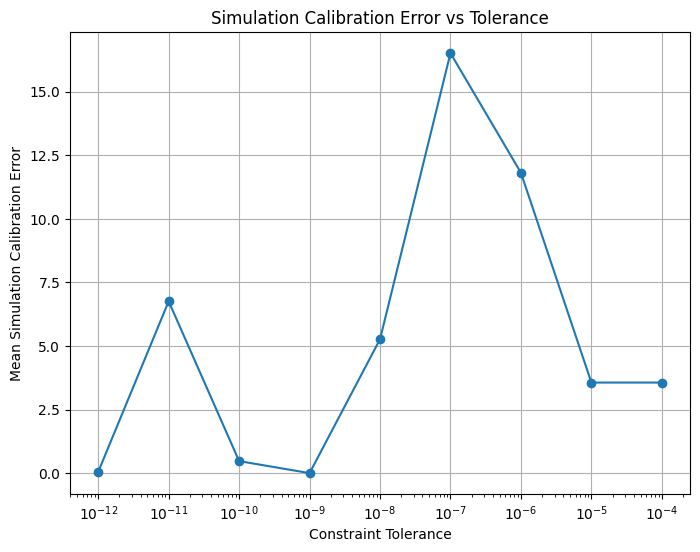

In [11]:
# Plot simulation calibration error vs tolerance
plt.figure(figsize=(8,6))
errors = []
for tol in tolerances:
    RESULTS_DIR = f"calibration_results/tolerance_{tol}"
    sim_cal_error = np.load(f"{RESULTS_DIR}/sim_cal_error.npy")
    mean_error = np.mean(sim_cal_error)
    errors.append(mean_error)

plt.plot(tolerances, errors, marker='o')
plt.xscale('log')
plt.xlabel('Constraint Tolerance')
plt.ylabel('Mean Simulation Calibration Error')
plt.title('Simulation Calibration Error vs Tolerance')
plt.grid()
plt.show()

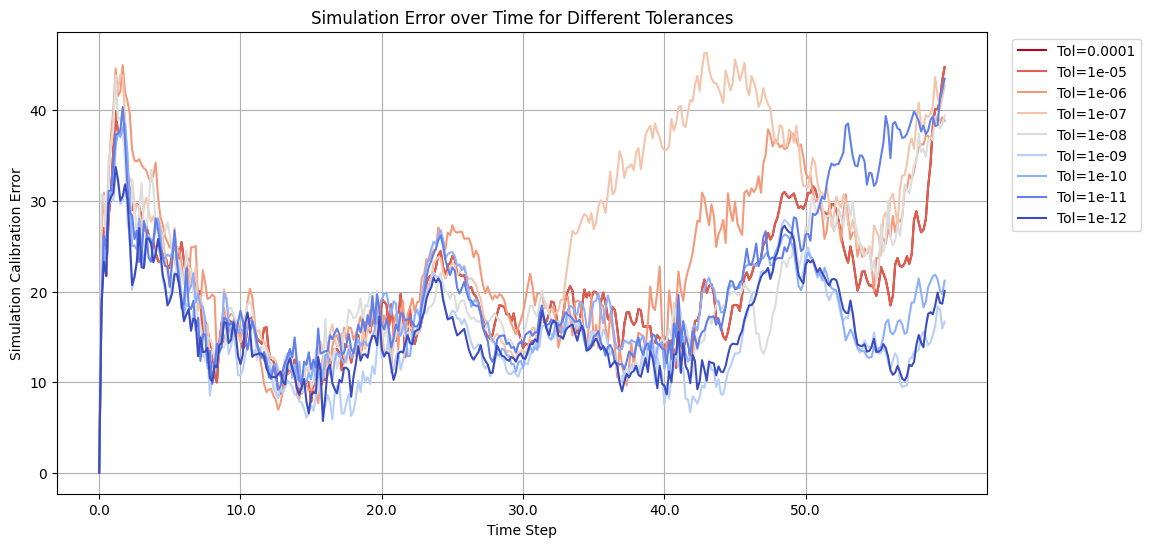

In [16]:
plt.figure(figsize=(12,6))

log_vals = -np.log10(tolerances)
norm = plt.Normalize(vmin=log_vals.min(), vmax=log_vals.max())
cmap = plt.cm.coolwarm_r

for tol, logv in zip(tolerances, log_vals):
    color = cmap(norm(logv))
    RESULTS_DIR = f"calibration_results/tolerance_{tol}"
    sim_cal_error = np.load(f"{RESULTS_DIR}/sim_gt_error.npy")
    plt.plot(sim_cal_error, label=f'Tol={tol}', color=color)
plt.xlabel('Time Step')
plt.ylabel('Simulation Calibration Error')
plt.title('Simulation Error over Time for Different Tolerances')
# Move legend outside of plot
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Change time axis to minutes
plt.xticks(ticks=np.arange(0, len(sim_cal_error), step=60), labels=np.arange(0, len(sim_cal_error)*10/60, step=10))

plt.grid()
plt.show()

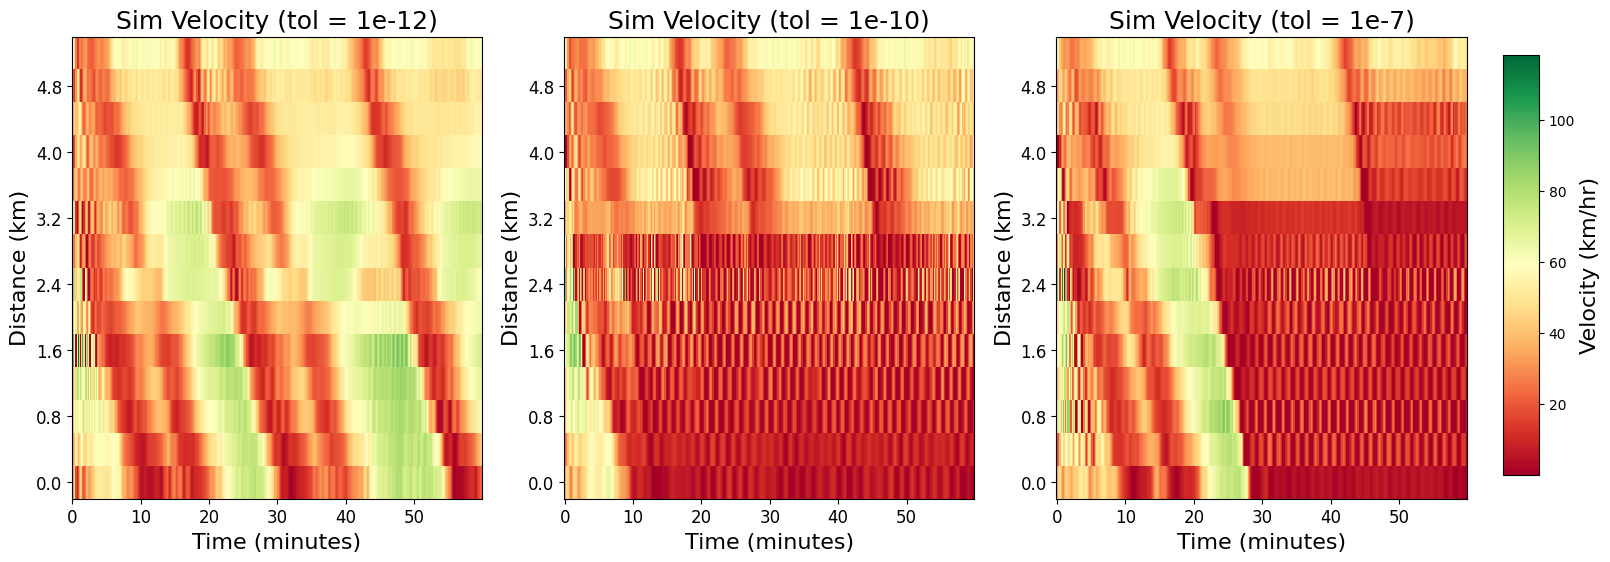

In [33]:
v_sim_high_tol = np.load("calibration_results/test_1e-7/v_sim.npy")[0:-1, :]
v_sim_low_tol = np.load("calibration_results/test/v_sim.npy")[0:-1, :]
v_sim_med_tol = np.load("calibration_results/test_1e-8/v_sim.npy")[0:-1, :]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Compute common color scale using all three sim arrays ---
vmin = min(
    np.min(v_sim_high_tol),
    np.min(v_sim_med_tol),
    np.min(v_sim_low_tol),
)
vmax = max(
    np.max(v_sim_high_tol),
    np.max(v_sim_med_tol),
    np.max(v_sim_low_tol),
)

# --- Simulation: low tolerance (e.g., tol = 1e-12) ---
im0 = axes[0].imshow(
    v_sim_low_tol.T,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    interpolation="none",
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_title("Sim Velocity (tol = 1e-12)")
axes[0].set_xlabel("Time (minutes)")
axes[0].set_ylabel("Distance (km)")

# --- Simulation: medium tolerance ---
im1 = axes[1].imshow(
    v_sim_med_tol.T,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    interpolation="none",
    vmin=vmin,
    vmax=vmax,
)
axes[1].set_title("Sim Velocity (tol = 1e-10)")
axes[1].set_xlabel("Time (minutes)")
axes[1].set_ylabel("Distance (km)")

# --- Simulation: high tolerance (e.g., tol = 1e-7) ---
im2 = axes[2].imshow(
    v_sim_high_tol.T,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    interpolation="none",
    vmin=vmin,
    vmax=vmax,
)
axes[2].set_title("Sim Velocity (tol = 1e-7)")
axes[2].set_xlabel("Time (minutes)")
axes[2].set_ylabel("Distance (km)")

# ---- One shared colorbar in its own axis ----
fig.subplots_adjust(right=0.90)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im0, cax=cbar_ax)
cbar.set_label("Velocity (km/hr)", fontsize=16)

# --- Convert x ticks to minutes (using high-tol sim for shape) ---
num_time_steps = v_sim_high_tol.shape[0]
time_step_indices = np.arange(0, num_time_steps, max(1, num_time_steps // 6))
time_step_labels = [f"{(i * T * 60):.0f}" for i in time_step_indices]

for ax in axes:
    ax.set_xticks(time_step_indices)
    ax.set_xticklabels(time_step_labels)

# --- Convert y axis to kilometers (using high-tol sim for shape) ---
num_segments = v_sim_high_tol.shape[1]
segment_indices = np.arange(0, num_segments, max(1, num_segments // 6))
segment_labels = [f"{(i * l):.1f}" for i in segment_indices]

for ax in axes:
    ax.set_yticks(segment_indices)
    ax.set_yticklabels(segment_labels)

# --- Label font sizes ---
for ax in axes:
    ax.title.set_fontsize(18)
    ax.xaxis.label.set_fontsize(16)
    ax.yaxis.label.set_fontsize(16)
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.show()





GT shape: (360, 14)
High tol sim shape: (360, 14)
Med tol sim shape: (360, 14)
Low tol sim shape: (360, 14)


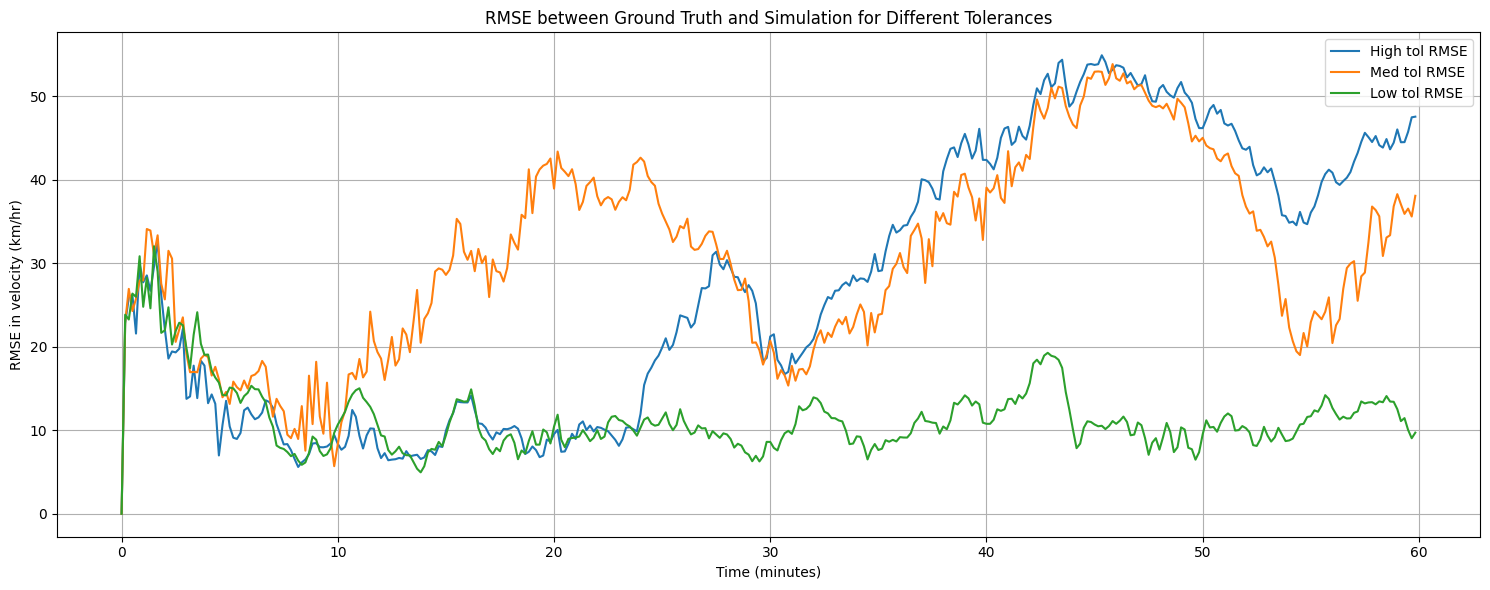

In [35]:
# Ground truth (same shape as sims)
v_gt = v_hat[:, 1:-1]

# Check shapes
print("GT shape:", v_gt.shape)
print("High tol sim shape:", v_sim_high_tol.shape)
print("Med tol sim shape:",  v_sim_med_tol.shape)
print("Low tol sim shape:",  v_sim_low_tol.shape)

# --- Compute RMSE over space (segments) for each time step ---
err_high = v_sim_high_tol - v_gt
err_med  = v_sim_med_tol  - v_gt
err_low  = v_sim_low_tol  - v_gt

rmse_high = np.sqrt(np.mean(err_high**2, axis=1))  # shape (num_time_steps,)
rmse_med  = np.sqrt(np.mean(err_med**2,  axis=1))
rmse_low  = np.sqrt(np.mean(err_low**2,  axis=1))

# --- Time axis in minutes ---
num_time_steps = v_gt.shape[0]
time_minutes = np.arange(num_time_steps) * T * 60  # T in hours

plt.figure(figsize=(15, 6))
plt.plot(time_minutes, rmse_high, label="High tol RMSE")
plt.plot(time_minutes, rmse_med,  label="Med tol RMSE")
plt.plot(time_minutes, rmse_low,  label="Low tol RMSE")

plt.xlabel("Time (minutes)")
plt.ylabel("RMSE in velocity (km/hr)")
plt.title("RMSE between Ground Truth and Simulation for Different Tolerances")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
